# 04 - Feature Engineering

## Objective

The goal of this notebook is to create a small number of meaningful features that may help the churn prediction model.

Feature engineering will be kept simple to avoid unnecessary complexity.

The main goals are:

- Create useful customer lifecycle features
- Summarize the number of subscribed services
- Preserve important original information
- Avoid data leakage
- Prepare the dataset for machine learning

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [3]:
df.shape

(7043, 22)

## Tenure Groups

Customer tenure is retained as a numerical feature because it contains useful continuous information.

A separate categorical `TenureGroup` feature is also created to make customer lifecycle stages easier to interpret.

The original `tenure` column will not be removed.

In [4]:
def create_tenure_group(tenure):
    if tenure <= 12:
        return "0-12 months"
    elif tenure <= 24:
        return "13-24 months"
    elif tenure <= 48:
        return "25-48 months"
    elif tenure <= 60:
        return "49-60 months"
    else:
        return "61+ months"

df["TenureGroup"] = df["tenure"].apply(create_tenure_group)

In [5]:
df["TenureGroup"].value_counts()

TenureGroup
0-12 months     2186
25-48 months    1594
61+ months      1407
13-24 months    1024
49-60 months     832
Name: count, dtype: int64

In [6]:
df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months
5,8,0-12 months
6,22,13-24 months
7,10,0-12 months
8,28,25-48 months
9,62,61+ months


## Total Services Subscribed

Customers who subscribe to more services may have a different level of engagement with the company.

A new `TotalServices` feature is created by counting the number of active services for each customer.

Only explicit `Yes` values are counted as subscribed services.

In [10]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_cols]
    .isin(["Yes"])
    .sum(axis=1)
)

In [11]:
df[service_cols + ["TotalServices"]].head()

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,TotalServices
0,No,No phone service,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,Yes,No,No,No,3
2,Yes,No,Yes,Yes,No,No,No,No,3
3,No,No phone service,Yes,No,Yes,Yes,No,No,3
4,Yes,No,No,No,No,No,No,No,1


In [12]:
df["TotalServices"].value_counts().sort_index()

TotalServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

In [13]:
df[["tenure", "TenureGroup", "TotalServices"]].head(10)

,tenure,TenureGroup,TotalServices
0,1,0-12 months,1
1,34,25-48 months,3
2,2,0-12 months,3
3,45,25-48 months,3
4,2,0-12 months,1
5,8,0-12 months,5
6,22,13-24 months,4
7,10,0-12 months,1
8,28,25-48 months,6
9,62,61+ months,3


In [14]:
df["TotalServices"].describe()

count    7043.000000
mean        3.362914
std         2.062031
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: TotalServices, dtype: float64

In [15]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_cols].isin(["Yes"]).sum(axis=1)
    + (df["InternetService"] != "No").astype(int)
)

## Total Services Subscribed

A `TotalServices` feature is created to represent the overall number of telecom services used by each customer.

The feature counts:

- Phone Service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies

Only active services are counted.

This provides a simple measure of how deeply a customer is engaged with the company's services.

In [16]:
df["TotalServices"].describe()

count    7043.000000
mean        4.146244
std         2.312720
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: TotalServices, dtype: float64

In [17]:
df["TotalServices"].value_counts().sort_index()

TotalServices
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64

In [18]:
services_churn = (
    df.groupby("TotalServices")["ChurnFlag"]
    .agg(["count", "mean"])
)

services_churn["ChurnRate"] = services_churn["mean"] * 100

services_churn

,count,mean,ChurnRate
TotalServices,,,
1,1264,0.109177,10.917722
2,859,0.309662,30.966240
3,846,0.449173,44.917258
4,965,0.364767,36.476684
5,922,0.313449,31.344902
6,908,0.255507,25.550661
7,676,0.224852,22.485207
8,395,0.124051,12.405063
9,208,0.052885,5.288462


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

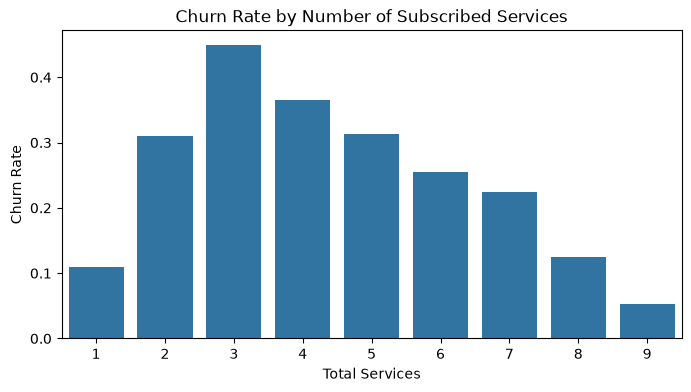

In [25]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=df,
    x="TotalServices",
    y="ChurnFlag",
    errorbar=None
)

plt.title("Churn Rate by Number of Subscribed Services")
plt.xlabel("Total Services")
plt.ylabel("Churn Rate")

plt.show()